# 균일 HSBM rho_n 변화 - Zhou theta 비랜덤 실험

이 노트북은 균일 HSBM의 다른 하이퍼파라미터를 고정하고 `rho_n`만 바꾸는 실험을 실행한다.

각 `rho_n`에서 `p_in = a_in * rho_n / n ** (m - 1)`, `p_out = b_out * rho_n / n ** (m - 1)`를 사용한다.

Spectral clustering은 Zhou operator `Theta = I - Delta`의 가장 큰 고유값에 대응하는 고유벡터를 사용한다.


In [1]:
from pathlib import Path
import gc
import json
import sys
import time
import tracemalloc
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

PROJECT_ROOT = Path.cwd()
for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / "src" / "common.py").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise RuntimeError("Could not find project root containing src/common.py")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.common import (
    generate_planted_uniform_hsbm_instance,
    normalize_rows_l2,
    zhou_normalized_laplacian,
)

EXPERIMENT_ID = "EXP-20260427-001"
EXPERIMENT_SLUG = "uniform_hsbm_rho_n_sweep_zhou_theta"
OUTDIR = PROJECT_ROOT / "experiments" / "균일 HSBM 실험" / "results" / f"{EXPERIMENT_ID}_{EXPERIMENT_SLUG}"
OUTDIR.mkdir(parents=True, exist_ok=True)

EXPERIMENT_ID, EXPERIMENT_SLUG, PROJECT_ROOT, OUTDIR


('EXP-20260427-001',
 'uniform_hsbm_rho_n_sweep_zhou_theta',
 PosixPath('/Users/eomjeonghyeon/Documents/github_project/python-rand-nla-research'),
 PosixPath('/Users/eomjeonghyeon/Documents/github_project/python-rand-nla-research/experiments/균일 HSBM 실험/results/EXP-20260427-001_uniform_hsbm_rho_n_sweep_zhou_theta'))

## 설정

`rho_n`만 바꾸고 나머지 모델 및 알고리즘 파라미터는 고정한다.


In [2]:
CONFIG = {
    "n": 5_000,
    "K": 3,
    "m": 3,
    "a_in": 36.0,
    "b_out": 4.0,
    "reps": 10,
    "seed": 20260427,
    "sampling": "sparse",
    "max_enumeration": 1_500_000,
    "normalize_embedding_rows": True,
    "eigsh_tol": 1e-6,
}

RHO_VALUES = [0.25, 0.5, 1.0, 2.0, 4.0, 8.0, 16.0]

CONFIG, RHO_VALUES


({'n': 5000,
  'K': 3,
  'm': 3,
  'a_in': 36.0,
  'b_out': 4.0,
  'reps': 10,
  'seed': 20260427,
  'sampling': 'sparse',
  'max_enumeration': 1500000,
  'normalize_embedding_rows': True,
  'eigsh_tol': 1e-06},
 [0.25, 0.5, 1.0, 2.0, 4.0, 8.0, 16.0])

## 보조 함수


In [3]:
def current_rss_mb():
    try:
        import psutil

        return psutil.Process().memory_info().rss / (1024.0 ** 2)
    except Exception:
        return np.nan


def measure_call(fn):
    gc.collect()
    rss_before_mb = current_rss_mb()
    tracemalloc.start()
    cpu_start = time.process_time()
    wall_start = time.perf_counter()
    value = fn()
    wall_clock_sec = time.perf_counter() - wall_start
    cpu_time_sec = time.process_time() - cpu_start
    current_bytes, peak_bytes = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    rss_after_mb = current_rss_mb()
    return value, {
        "cpu_time_sec": float(cpu_time_sec),
        "wall_clock_sec": float(wall_clock_sec),
        "peak_traced_memory_mb": float(peak_bytes / (1024.0 ** 2)),
        "rss_before_mb": float(rss_before_mb) if np.isfinite(rss_before_mb) else np.nan,
        "rss_after_mb": float(rss_after_mb) if np.isfinite(rss_after_mb) else np.nan,
        "rss_delta_mb": float(rss_after_mb - rss_before_mb)
        if np.isfinite(rss_before_mb) and np.isfinite(rss_after_mb)
        else np.nan,
    }


def aligned_misclassification_rate(y_true, y_pred, K):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    conf = np.zeros((K, K), dtype=int)
    for t, p in zip(y_true, y_pred):
        if 0 <= t < K and 0 <= p < K:
            conf[t, p] += 1
    true_ids, pred_ids = linear_sum_assignment(-conf)
    pred_to_true = {int(pred): int(true) for true, pred in zip(true_ids, pred_ids)}
    y_aligned = np.array([pred_to_true.get(int(p), int(p)) for p in y_pred], dtype=int)
    return float(np.mean(y_aligned != y_true)), y_aligned, conf


def hypergraph_vertex_degree_stats(n, hyperedges):
    degrees = np.zeros(int(n), dtype=float)
    for edge in hyperedges:
        for v in edge:
            degrees[int(v)] += 1.0
    return {
        "num_isolated_nodes": int(np.sum(degrees == 0)),
        "isolated_fraction": float(np.mean(degrees == 0)) if n > 0 else 0.0,
        "hypergraph_degree_mean": float(degrees.mean()) if n > 0 else 0.0,
        "hypergraph_degree_max": float(degrees.max()) if n > 0 else 0.0,
    }


def spectral_cluster_from_zhou_theta(theta, K, rng, normalize_rows=True, eigsh_tol=1e-6):
    n = int(theta.shape[0])
    theta = ((theta + theta.T) * 0.5).tocsr()
    total_start = time.perf_counter()
    timings = {}

    t0 = time.perf_counter()
    try:
        if n <= K + 1:
            vals, vecs = np.linalg.eigh(theta.toarray())
        else:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", category=UserWarning)
                vals, vecs = spla.eigsh(
                    theta,
                    k=K,
                    which="LA",
                    tol=float(eigsh_tol),
                    v0=rng.normal(size=n),
                )
    except Exception:
        vals, vecs = np.linalg.eigh(theta.toarray())
    order = np.argsort(vals)[-K:][::-1]
    top_vals = vals[order]
    top_vecs = vecs[:, order]
    U = top_vecs
    timings["eigen_decomposition_wall_sec"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    if normalize_rows:
        U = normalize_rows_l2(U)
    timings["embedding_normalize_wall_sec"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    random_state = int(rng.integers(1, 2**31 - 1))
    labels = KMeans(n_clusters=K, n_init=20, random_state=random_state).fit_predict(U)
    timings["kmeans_wall_sec"] = time.perf_counter() - t0
    timings["spectral_clustering_wall_sec"] = time.perf_counter() - total_start
    return labels, {
        "zhou_theta_nnz": int(theta.nnz),
        **timings,
    }


def run_one_rep(rho_n, rep, config):
    n = int(config["n"])
    K = int(config["K"])
    m = int(config["m"])
    rho_n = float(rho_n)
    seed = int(config["seed"] + 1_000_003 * int(round(rho_n * 1_000_000)) + int(rep))
    rng = np.random.default_rng(seed)
    timings = {}

    t0 = time.perf_counter()
    hyperedges, y_true, Theta_true, gen_stats = generate_planted_uniform_hsbm_instance(
        n=n,
        K=K,
        d=m,
        a_d=float(config["a_in"]),
        b_d=float(config["b_out"]),
        rho_n=rho_n,
        rng=rng,
        sampling=config["sampling"],
        max_enumeration=int(config["max_enumeration"]),
        clip=False,
    )
    p_in = float(gen_stats["p_in"])
    p_out = float(gen_stats["p_out"])
    timings["generation_wall_sec"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    L = zhou_normalized_laplacian(n=n, hyperedges=hyperedges)
    theta = (sp.eye(n, format="csr", dtype=float) - L).tocsr()
    theta.eliminate_zeros()
    timings["zhou_theta_build_wall_sec"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    y_pred, spectral_stats = spectral_cluster_from_zhou_theta(
        theta=theta,
        K=K,
        rng=rng,
        normalize_rows=bool(config["normalize_embedding_rows"]),
        eigsh_tol=float(config["eigsh_tol"]),
    )
    timings["spectral_clustering_wall_sec"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    mis, y_aligned, conf = aligned_misclassification_rate(y_true, y_pred, K)
    ari = adjusted_rand_score(y_true, y_pred)
    nmi = normalized_mutual_info_score(y_true, y_pred)
    timings["metric_wall_sec"] = time.perf_counter() - t0

    record = {
        "n": n,
        "rho_n": rho_n,
        "rep": int(rep),
        "seed": seed,
        "K": K,
        "m": m,
        "num_hyperedges_total": int(len(hyperedges)),
        "misclassification_rate": mis,
        "ARI": float(ari),
        "NMI": float(nmi),
        **timings,
        **hypergraph_vertex_degree_stats(n, hyperedges),
        **spectral_stats,
    }
    record["algorithm_total_wall_sec"] = float(
        record["generation_wall_sec"]
        + record["zhou_theta_build_wall_sec"]
        + record["eigen_decomposition_wall_sec"]
        + record["embedding_normalize_wall_sec"]
        + record["kmeans_wall_sec"]
    )
    record["p_in"] = float(p_in)
    record["p_out"] = float(p_out)
    record["sampling_mode"] = gen_stats.get("sampling_mode", "")
    return record


def run_one_rep_measured(rho_n, rep, config):
    record, measurement = measure_call(lambda: run_one_rep(rho_n=rho_n, rep=rep, config=config))
    record.update(measurement)
    return record


def run_rho_experiment(rho_n, reps=None, config=None):
    if config is None:
        config = CONFIG
    if reps is None:
        reps = int(config["reps"])

    rows = []
    for rep in range(1, reps + 1):
        row = run_one_rep_measured(rho_n=rho_n, rep=rep, config=config)
        rows.append(row)
        print(
            f"rho_n={rho_n:7.3f} rep={rep:2d}/{reps:<2d} "
            f"edges={row['num_hyperedges_total']:8d} "
            f"degree={row['hypergraph_degree_mean']:.2f} "
            f"isolated={row['isolated_fraction']:.4f} "
            f"mis={row['misclassification_rate']:.4f} "
            f"ARI={row['ARI']:.4f} NMI={row['NMI']:.4f} "
            f"wall={row['wall_clock_sec']:.3f}s "
            f"peak={row['peak_traced_memory_mb']:.1f}MB"
        )

    df = pd.DataFrame(rows)
    display(df)
    return df


def summarize_by_rho(df_raw):
    return df_raw.groupby("rho_n", as_index=False).agg(
        reps=("rep", "count"),
        hyperedges_mean=("num_hyperedges_total", "mean"),
        hyperedges_std=("num_hyperedges_total", "std"),
        degree_mean=("hypergraph_degree_mean", "mean"),
        degree_std=("hypergraph_degree_mean", "std"),
        isolated_fraction_mean=("isolated_fraction", "mean"),
        isolated_fraction_std=("isolated_fraction", "std"),
        misclassification_mean=("misclassification_rate", "mean"),
        misclassification_std=("misclassification_rate", "std"),
        ari_mean=("ARI", "mean"),
        ari_std=("ARI", "std"),
        nmi_mean=("NMI", "mean"),
        nmi_std=("NMI", "std"),
        generation_wall_sec_mean=("generation_wall_sec", "mean"),
        zhou_theta_build_wall_sec_mean=("zhou_theta_build_wall_sec", "mean"),
        eigen_decomposition_wall_sec_mean=("eigen_decomposition_wall_sec", "mean"),
        kmeans_wall_sec_mean=("kmeans_wall_sec", "mean"),
        spectral_clustering_wall_sec_mean=("spectral_clustering_wall_sec", "mean"),
        algorithm_total_wall_sec_mean=("algorithm_total_wall_sec", "mean"),
        cpu_time_sec_mean=("cpu_time_sec", "mean"),
        wall_clock_sec_mean=("wall_clock_sec", "mean"),
        peak_traced_memory_mb_mean=("peak_traced_memory_mb", "mean"),
        rss_delta_mb_mean=("rss_delta_mb", "mean"),
    )


## rho_n 변화 실험 실행


In [4]:
frames = []
for rho_n in RHO_VALUES:
    frames.append(run_rho_experiment(rho_n))

df_raw = pd.concat(frames, ignore_index=True)
summary = summarize_by_rho(df_raw)

display(summary)


rho_n=  0.250 rep= 1/10 edges=    1591 degree=0.95 isolated=0.3806 mis=0.6446 ARI=0.0015 NMI=0.0024 wall=0.514s peak=2.8MB


rho_n=  0.250 rep= 2/10 edges=    1554 degree=0.93 isolated=0.3876 mis=0.6526 ARI=0.0003 NMI=0.0010 wall=0.266s peak=2.7MB


rho_n=  0.250 rep= 3/10 edges=    1555 degree=0.93 isolated=0.3938 mis=0.6488 ARI=0.0014 NMI=0.0025 wall=0.212s peak=2.7MB


rho_n=  0.250 rep= 4/10 edges=    1563 degree=0.94 isolated=0.3990 mis=0.6594 ARI=-0.0001 NMI=0.0002 wall=0.294s peak=2.7MB


rho_n=  0.250 rep= 5/10 edges=    1580 degree=0.95 isolated=0.3870 mis=0.6602 ARI=0.0001 NMI=0.0005 wall=0.252s peak=2.8MB


...

rho_n= 16.000 rep= 8/10 edges=  100631 degree=60.38 isolated=0.0000 mis=0.0000 ARI=1.0000 NMI=1.0000 wall=4.299s peak=50.3MB


rho_n= 16.000 rep= 9/10 edges=  100566 degree=60.34 isolated=0.0000 mis=0.0000 ARI=1.0000 NMI=1.0000 wall=3.937s peak=50.2MB


rho_n= 16.000 rep=10/10 edges=  100043 degree=60.03 isolated=0.0000 mis=0.0000 ARI=1.0000 NMI=1.0000 wall=4.186s peak=49.9MB


,n,rho_n,rep,seed,K,m,num_hyperedges_total,misclassification_rate,ARI,NMI,...,algorithm_total_wall_sec,p_in,p_out,sampling_mode,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,5000,16.0,1,16000068260428,3,3,100514,0.0,1.0,1.0,...,3.534525,0.000023,0.000003,sparse,5.949876,3.937655,50.172261,292.765625,310.453125,17.687500
1,5000,16.0,2,16000068260429,3,3,100207,0.0,1.0,1.0,...,3.602577,0.000023,0.000003,sparse,6.178231,3.977105,50.052634,304.453125,338.109375,33.656250
2,5000,16.0,3,16000068260430,3,3,100080,0.0,1.0,1.0,...,3.741131,0.000023,0.000003,sparse,6.084478,4.146076,49.972647,334.109375,351.875000,17.765625
3,5000,16.0,4,16000068260431,3,3,100562,0.0,1.0,1.0,...,3.629837,0.000023,0.000003,sparse,6.073718,4.020919,50.195281,347.875000,365.062500,17.187500
4,5000,16.0,5,16000068260432,3,3,100460,0.0,1.0,1.0,...,3.715924,0.000023,0.000003,sparse,6.320677,4.086039,50.164131,363.062500,365.234375,2.171875
5,5000,16.0,6,16000068260433,3,3,100374,0.0,1.0,1.0,...,3.500288,0.000023,0.000003,sparse,5.985778,3.885030,50.126600,364.234375,365.140625,0.906250
6,5000,16.0,7,16000068260434,3,3,100411,0.0,1.0,1.0,...,3.540635,0.000023,0.000003,sparse,6.017220,3.920988,50.140068,365.140625,367.546875,2.406250
7,5000,16.0,8,16000068260435,3,3,100631,0.0,1.0,1.0,...,3.915388,0.000023,0.000003,sparse,6.417267,4.298729,50.253156,367.546875,378.140625,10.593750
8,5000,16.0,9,16000068260436,3,3,100566,0.0,1.0,1.0,...,3.558854,0.000023,0.000003,sparse,6.053205,3.936641,50.211324,378.140625,384.093750,5.953125
9,5000,16.0,10,16000068260437,3,3,100043,0.0,1.0,1.0,...,3.768662,0.000023,0.000003,sparse,6.192953,4.186009,49.946161,384.093750,386.093750,2.000000


,rho_n,reps,hyperedges_mean,hyperedges_std,degree_mean,degree_std,isolated_fraction_mean,isolated_fraction_std,misclassification_mean,misclassification_std,...,generation_wall_sec_mean,zhou_theta_build_wall_sec_mean,eigen_decomposition_wall_sec_mean,kmeans_wall_sec_mean,spectral_clustering_wall_sec_mean,algorithm_total_wall_sec_mean,cpu_time_sec_mean,wall_clock_sec_mean,peak_traced_memory_mb_mean,rss_delta_mb_mean
0,0.25,10,1561.3,18.529556,0.93678,0.011118,0.39128,0.007729,0.65344,0.005547,...,0.071576,0.008130,0.042787,0.150912,0.193865,0.273565,1.871570,0.301835,2.751732,-2.065625
1,0.50,10,3145.4,56.502114,1.88724,0.033901,0.15244,0.006031,0.65176,0.010882,...,0.119622,0.010089,0.014234,0.181635,0.195976,0.325681,2.262574,0.360594,3.349685,0.762500
2,1.00,10,6242.8,82.340486,3.74568,0.049404,0.02276,0.001306,0.62670,0.036111,...,0.205383,0.015558,0.009659,0.225807,0.235546,0.456482,3.017161,0.500582,4.484225,0.926562
3,2.00,10,12549.8,73.237513,7.52988,0.043943,0.00074,0.000267,0.10340,0.007003,...,0.437367,0.027781,0.006561,0.108849,0.115502,0.580646,2.368037,0.645361,6.893623,0.898438
4,4.00,10,25141.5,216.790349,15.08490,0.130074,0.00000,0.000000,0.01708,0.001698,...,0.912988,0.057341,0.006066,0.075983,0.082142,1.052465,2.703816,1.174150,13.147626,0.706250
5,8.00,10,50289.2,206.855183,30.17352,0.124113,0.00000,0.000000,0.00060,0.000353,...,1.704869,0.114262,0.008361,0.071451,0.079923,1.899050,4.073564,2.137275,25.580431,2.468750
6,16.00,10,100384.8,207.990812,60.23088,0.124794,0.00000,0.000000,0.00000,0.000000,...,3.355144,0.224011,0.009494,0.062058,0.071632,3.650782,6.127340,4.039519,50.123426,11.032813


## 결과 저장


In [5]:
raw_path = OUTDIR / f"{EXPERIMENT_ID}_{EXPERIMENT_SLUG}_raw.csv"
summary_path = OUTDIR / f"{EXPERIMENT_ID}_{EXPERIMENT_SLUG}_summary.csv"
config_path = OUTDIR / f"{EXPERIMENT_ID}_{EXPERIMENT_SLUG}_config.json"

df_raw.to_csv(raw_path, index=False)
summary.to_csv(summary_path, index=False)
with config_path.open("w", encoding="utf-8") as f:
    json.dump({"CONFIG": CONFIG, "RHO_VALUES": RHO_VALUES}, f, indent=2)

raw_path, summary_path, config_path


(PosixPath('/Users/eomjeonghyeon/Documents/github_project/python-rand-nla-research/experiments/균일 HSBM 실험/results/EXP-20260427-001_uniform_hsbm_rho_n_sweep_zhou_theta/EXP-20260427-001_uniform_hsbm_rho_n_sweep_zhou_theta_raw.csv'),
 PosixPath('/Users/eomjeonghyeon/Documents/github_project/python-rand-nla-research/experiments/균일 HSBM 실험/results/EXP-20260427-001_uniform_hsbm_rho_n_sweep_zhou_theta/EXP-20260427-001_uniform_hsbm_rho_n_sweep_zhou_theta_summary.csv'),
 PosixPath('/Users/eomjeonghyeon/Documents/github_project/python-rand-nla-research/experiments/균일 HSBM 실험/results/EXP-20260427-001_uniform_hsbm_rho_n_sweep_zhou_theta/EXP-20260427-001_uniform_hsbm_rho_n_sweep_zhou_theta_config.json'))

## 그림


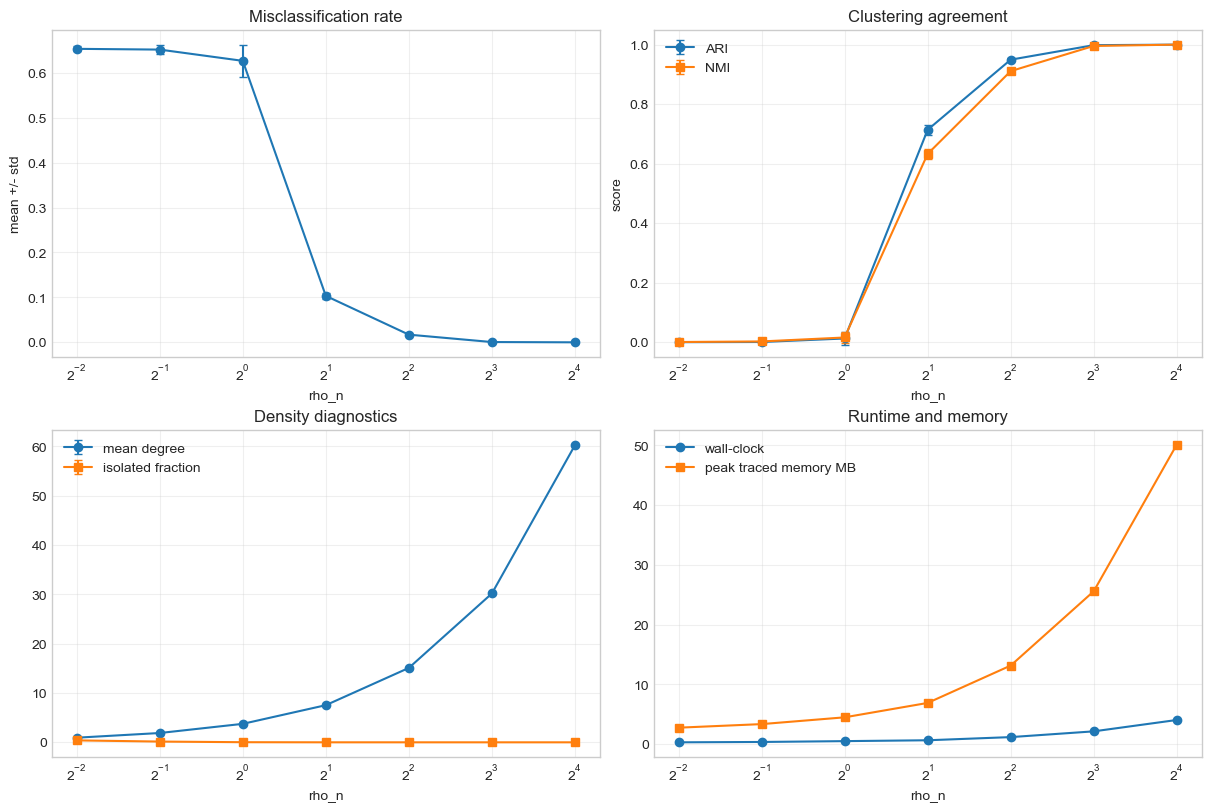

PosixPath('/Users/eomjeonghyeon/Documents/github_project/python-rand-nla-research/experiments/균일 HSBM 실험/results/EXP-20260427-001_uniform_hsbm_rho_n_sweep_zhou_theta/EXP-20260427-001_uniform_hsbm_rho_n_sweep_zhou_theta_summary.png')

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
x = summary["rho_n"].to_numpy()

axes[0, 0].errorbar(
    x,
    summary["misclassification_mean"],
    yerr=summary["misclassification_std"].fillna(0.0),
    marker="o",
    capsize=3,
)
axes[0, 0].set_xscale("log", base=2)
axes[0, 0].set_title("Misclassification rate")
axes[0, 0].set_xlabel("rho_n")
axes[0, 0].set_ylabel("mean +/- std")
axes[0, 0].grid(alpha=0.3)

axes[0, 1].errorbar(x, summary["ari_mean"], yerr=summary["ari_std"].fillna(0.0), marker="o", capsize=3, label="ARI")
axes[0, 1].errorbar(x, summary["nmi_mean"], yerr=summary["nmi_std"].fillna(0.0), marker="s", capsize=3, label="NMI")
axes[0, 1].set_xscale("log", base=2)
axes[0, 1].set_title("Clustering agreement")
axes[0, 1].set_xlabel("rho_n")
axes[0, 1].set_ylabel("score")
axes[0, 1].set_ylim(-0.05, 1.05)
axes[0, 1].grid(alpha=0.3)
axes[0, 1].legend()

axes[1, 0].errorbar(x, summary["degree_mean"], yerr=summary["degree_std"].fillna(0.0), marker="o", capsize=3, label="mean degree")
axes[1, 0].errorbar(x, summary["isolated_fraction_mean"], yerr=summary["isolated_fraction_std"].fillna(0.0), marker="s", capsize=3, label="isolated fraction")
axes[1, 0].set_xscale("log", base=2)
axes[1, 0].set_title("Density diagnostics")
axes[1, 0].set_xlabel("rho_n")
axes[1, 0].grid(alpha=0.3)
axes[1, 0].legend()

axes[1, 1].errorbar(x, summary["wall_clock_sec_mean"], marker="o", capsize=3, label="wall-clock")
axes[1, 1].errorbar(x, summary["peak_traced_memory_mb_mean"], marker="s", capsize=3, label="peak traced memory MB")
axes[1, 1].set_xscale("log", base=2)
axes[1, 1].set_title("Runtime and memory")
axes[1, 1].set_xlabel("rho_n")
axes[1, 1].grid(alpha=0.3)
axes[1, 1].legend()

fig_path = OUTDIR / f"{EXPERIMENT_ID}_{EXPERIMENT_SLUG}_summary.png"
fig.savefig(fig_path, dpi=180, bbox_inches="tight")
plt.show()

fig_path
